In [59]:
import numpy as np
import pandas as pd

In [60]:
pip install pandas nltk matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


In [61]:

!pip install pandas numpy matplotlib seaborn nltk



In [62]:
import nltk
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sivas\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [63]:
!pip install notebook


In [64]:
books = pd.read_csv('books.csv')
users = pd.read_csv('users.csv')
ratings = pd.read_csv('ratings.csv')

C:\Users\sivas\AppData\Local\Temp\ipykernel_24756\3819754567.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('books.csv')


In [65]:
books['Image-URL-M'][1]

'http://images.amazon.com/images/P/0002005018.01.MZZZZZZZ.jpg'

In [66]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [67]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [68]:
print(books.shape)
print(ratings.shape)
print(users.shape)

(271360, 8)
(1149780, 3)
(278858, 3)


In [69]:
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [70]:
users.isnull().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [71]:
ratings.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [72]:
books.duplicated().sum()

np.int64(0)

In [73]:
ratings.duplicated().sum()

np.int64(0)

In [74]:
users.duplicated().sum()

np.int64(0)

## Popularity Based Recommender System

In [75]:
ratings_with_name = ratings.merge(books,on='ISBN')

In [76]:
num_rating_df = ratings_with_name.groupby('Book-Title').count()['Book-Rating'].reset_index()
num_rating_df.rename(columns={'Book-Rating':'num_ratings'},inplace=True)
num_rating_df

,Book-Title,num_ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241066,Ã?Â?lpiraten.,2
241067,Ã?Â?rger mit Produkt X. Roman.,4
241068,Ã?Â?sterlich leben.,1
241069,Ã?Â?stlich der Berge.,3


In [77]:
print(ratings_with_name.dtypes)


User-ID                 int64
ISBN                   object
Book-Rating             int64
Book-Title             object
Book-Author            object
Year-Of-Publication    object
Publisher              object
Image-URL-S            object
Image-URL-M            object
Image-URL-L            object
dtype: object


In [78]:
ratings_with_name['Book-Rating'] = pd.to_numeric(ratings_with_name['Book-Rating'], errors='coerce')


In [79]:
ratings_with_name.dropna(subset=['Book-Rating'], inplace=True)


In [80]:
avg_rating_df = ratings_with_name.groupby('Book-Title')['Book-Rating'].mean().reset_index()
avg_rating_df.rename(columns={'Book-Rating': 'avg_rating'}, inplace=True)
avg_rating_df

,Book-Title,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
241066,Ã?Â?lpiraten.,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,5.250000
241068,Ã?Â?sterlich leben.,7.000000
241069,Ã?Â?stlich der Berge.,2.666667


In [81]:
popular_df = num_rating_df.merge(avg_rating_df,on='Book-Title')
popular_df

,Book-Title,num_ratings,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
241066,Ã?Â?lpiraten.,2,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
241068,Ã?Â?sterlich leben.,1,7.000000
241069,Ã?Â?stlich der Berge.,3,2.666667


In [82]:
popular_df = popular_df[popular_df['num_ratings']>=250].sort_values('avg_rating',ascending=False).head(50)

In [83]:
popular_df = popular_df.merge(books,on='Book-Title').drop_duplicates('Book-Title')[['Book-Title','Book-Author','Image-URL-M','num_ratings','avg_rating']]

In [84]:
popular_df['Image-URL-M'][0]

'http://images.amazon.com/images/P/0439136350.01.MZZZZZZZ.jpg'

## Collaborative Filtering Based Recommender System

In [85]:
x = ratings_with_name.groupby('User-ID').count()['Book-Rating'] > 200
padhe_likhe_users = x[x].index

In [86]:
filtered_rating = ratings_with_name[ratings_with_name['User-ID'].isin(padhe_likhe_users)]

In [87]:
y = filtered_rating.groupby('Book-Title').count()['Book-Rating']>=50

In [88]:
famous_books = y[y].index

In [89]:
final_ratings = filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]

In [90]:
pt = final_ratings.pivot_table(index='Book-Title',columns='User-ID',values='Book-Rating')

In [91]:
pt.fillna(0,inplace=True)

In [92]:
pt

User-ID,254,2276,2766,2977,3363,4017,4385,6251,6323,6543,...,271705,273979,274004,274061,274301,274308,275970,277427,277639,278418
Book-Title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A Bend in the Road,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Year of Wonders,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
You Belong To Me,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Zen and the Art of Motorcycle Maintenance: An Inquiry into Values,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [93]:
from sklearn.metrics.pairwise import cosine_similarity

In [94]:
similarity_scores = cosine_similarity(pt)

In [95]:
similarity_scores.shape

(706, 706)

In [96]:
def recommend(book_name):
    # index fetch
    index = np.where(pt.index==book_name)[0][0]
    similar_items = sorted(list(enumerate(similarity_scores[index])),key=lambda x:x[1],reverse=True)[1:5]
    
    data = []
    for i in similar_items:
        item = []
        temp_df = books[books['Book-Title'] == pt.index[i[0]]]
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Title'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Book-Author'].values))
        item.extend(list(temp_df.drop_duplicates('Book-Title')['Image-URL-M'].values))
        
        data.append(item)
    
    return data

In [104]:
recommend('Midnight')

[['Winter Moon',
  'Dean R. Koontz',
  'http://images.amazon.com/images/P/0553582933.01.MZZZZZZZ.jpg'],
 ['Dark Rivers of the Heart',
  'Dean R. Koontz',
  'http://images.amazon.com/images/P/034539657X.01.MZZZZZZZ.jpg'],
 ['Shadowfires',
  'Dean R. Koontz',
  'http://images.amazon.com/images/P/0425136981.01.MZZZZZZZ.jpg'],
 ['While My Pretty One Sleeps',
  'Mary Higgins Clark',
  'http://images.amazon.com/images/P/0671673688.01.MZZZZZZZ.jpg']]

In [36]:
pt.index[545]

"The Handmaid's Tale"

In [37]:
import pickle
pickle.dump(popular_df,open('popular.pkl','wb'))

In [38]:
books.drop_duplicates('Book-Title')

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...
...,...,...,...,...,...,...,...,...
271354,0449906736,Flashpoints: Promise and Peril in a New World,Robin Wright,1993,Ballantine Books,http://images.amazon.com/images/P/0449906736.0...,http://images.amazon.com/images/P/0449906736.0...,http://images.amazon.com/images/P/0449906736.0...
271356,0525447644,From One to One Hundred,Teri Sloat,1991,Dutton Books,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...,http://images.amazon.com/images/P/0525447644.0...
271357,006008667X,Lily Dale : The True Story of the Town that Ta...,Christine Wicker,2004,HarperSanFrancisco,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...,http://images.amazon.com/images/P/006008667X.0...
271358,0192126040,Republic (World's Classics),Plato,1996,Oxford University Press,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...,http://images.amazon.com/images/P/0192126040.0...


In [39]:
pickle.dump(pt,open('pt.pkl','wb'))
pickle.dump(books,open('books.pkl','wb'))
pickle.dump(similarity_scores,open('similarity_scores.pkl','wb'))

In [40]:
import pickle
import pandas as pd

# Step 1: Try loading with the wrong encoding if needed (just to read it)
with open('popular.pkl', 'rb') as f:
    data = pickle.load(f)

# Optional: Preview data
print(data if isinstance(data, pd.DataFrame) else type(data))

# Step 2: Save it again using binary format properly
with open('popular_fixed.pkl', 'wb') as f:
    pickle.dump(data, f)

print("✅ Saved 'popular_fixed.pkl' correctly.")


                                            Book-Title  \
0    Harry Potter and the Prisoner of Azkaban (Book 3)   
3         Harry Potter and the Goblet of Fire (Book 4)   
5       Harry Potter and the Sorcerer's Stone (Book 1)   
9    Harry Potter and the Order of the Phoenix (Boo...   
13    Harry Potter and the Chamber of Secrets (Book 2)   
16   The Hobbit : The Enchanting Prelude to The Lor...   
17   The Fellowship of the Ring (The Lord of the Ri...   
26   Harry Potter and the Sorcerer's Stone (Harry P...   
28      The Two Towers (The Lord of the Rings, Part 2)   
39                               To Kill a Mockingbird   
47                                   The Da Vinci Code   
53                  The Five People You Meet in Heaven   
55                              The Catcher in the Rye   
62                           The Lovely Bones: A Novel   
63                                                1984   
72                            Prodigal Summer: A Novel   
73            

In [45]:
import pickle
import pandas as pd

# Step 1: Try loading with the wrong encoding if needed (just to read it)
with open('pt.pkl', 'rb') as f:
    data = pickle.load(f)

# Optional: Preview data
print(data if isinstance(data, pd.DataFrame) else type(data))

# Step 2: Save it again using binary format properly
with open('pt_fixed.pkl', 'wb') as f:
    pickle.dump(data, f)

print("✅ Saved 'popular_fixed.pkl' correctly.")


User-ID                                             254     2276    2766    \
Book-Title                                                                   
1984                                                   9.0     0.0     0.0   
1st to Die: A Novel                                    0.0     0.0     0.0   
2nd Chance                                             0.0    10.0     0.0   
4 Blondes                                              0.0     0.0     0.0   
A Bend in the Road                                     0.0     0.0     7.0   
...                                                    ...     ...     ...   
Year of Wonders                                        0.0     0.0     0.0   
You Belong To Me                                       0.0     0.0     0.0   
Zen and the Art of Motorcycle Maintenance: An I...     0.0     0.0     0.0   
Zoya                                                   0.0     0.0     0.0   
\O\" Is for Outlaw"                                    0.0     0

In [46]:
import pickle
import pandas as pd

# Step 1: Try loading with the wrong encoding if needed (just to read it)
with open('books.pkl', 'rb') as f:
    data = pickle.load(f)

# Optional: Preview data
print(data if isinstance(data, pd.DataFrame) else type(data))

# Step 2: Save it again using binary format properly
with open('books_fixed.pkl', 'wb') as f:
    pickle.dump(data, f)

print("✅ Saved 'popular_fixed.pkl' correctly.")


              ISBN                                         Book-Title  \
0       0195153448                                Classical Mythology   
1       0002005018                                       Clara Callan   
2       0060973129                               Decision in Normandy   
3       0374157065  Flu: The Story of the Great Influenza Pandemic...   
4       0393045218                             The Mummies of Urumchi   
...            ...                                                ...   
271355  0440400988                         There's a Bat in Bunk Five   
271356  0525447644                            From One to One Hundred   
271357  006008667X  Lily Dale : The True Story of the Town that Ta...   
271358  0192126040                        Republic (World's Classics)   
271359  0767409752  A Guided Tour of Rene Descartes' Meditations o...   

                 Book-Author Year-Of-Publication  \
0         Mark P. O. Morford                2002   
1       Richard Bru

In [47]:
import pickle
import pandas as pd

# Step 1: Try loading with the wrong encoding if needed (just to read it)
with open('similarity_scores.pkl', 'rb') as f:
    data = pickle.load(f)

# Optional: Preview data
print(data if isinstance(data, pd.DataFrame) else type(data))

# Step 2: Save it again using binary format properly
with open('similarity_scores_fixed.pkl', 'wb') as f:
    pickle.dump(data, f)

print("✅ Saved 'popular_fixed.pkl' correctly.")


<class 'numpy.ndarray'>
✅ Saved 'popular_fixed.pkl' correctly.


In [ ]:
#Sentiment_Analysis_Book_Recommendation

In [47]:
# Install necessary libraries
!pip install pandas nltk matplotlib seaborn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sivas\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [48]:
# Load the datasets
books = pd.read_csv('Books.csv')
ratings = pd.read_csv('Ratings.csv')
users = pd.read_csv('Users.csv')

# Display basic info
books.head(), ratings.head(), users.head()


C:\Users\sivas\AppData\Local\Temp\ipykernel_24756\1997925008.py:2: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('Books.csv')


(         ISBN                                         Book-Title  \
 0  0195153448                                Classical Mythology   
 1  0002005018                                       Clara Callan   
 2  0060973129                               Decision in Normandy   
 3  0374157065  Flu: The Story of the Great Influenza Pandemic...   
 4  0393045218                             The Mummies of Urumchi   
 
             Book-Author Year-Of-Publication                   Publisher  \
 0    Mark P. O. Morford                2002     Oxford University Press   
 1  Richard Bruce Wright                2001       HarperFlamingo Canada   
 2          Carlo D'Este                1991             HarperPerennial   
 3      Gina Bari Kolata                1999        Farrar Straus Giroux   
 4       E. J. W. Barber                1999  W. W. Norton &amp; Company   
 
                                          Image-URL-S  \
 0  http://images.amazon.com/images/P/0195153448.0...   
 1  http://i

In [49]:
# Merge datasets: Ratings + Books + Users
merged_df = ratings.merge(books, on='ISBN')
merged_df = merged_df.merge(users, on='User-ID')
merged_df.head()


,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L,Location,Age
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,"tyler, texas, usa",NaN
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,"seattle, washington, usa",NaN
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,"h, new south wales, australia",16.0
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,"rijeka, n/a, croatia",16.0
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,"rijeka, n/a, croatia",16.0


In [50]:
# Check if there is any textual review column (you may need to adapt this based on your dataset structure)
# If not, you can simulate some review texts for demonstration
if 'Review' not in merged_df.columns:
    # Simulating text reviews based on rating
    def generate_fake_review(rating):
        if rating >= 8:
            return "Absolutely loved it. Great plot and characters!"
        elif rating >= 5:
            return "It was decent. Some parts were interesting."
        elif rating > 0:
            return "Didn't enjoy it much. Was boring in places."
        else:
            return np.nan
    
    merged_df['Review'] = merged_df['Book-Rating'].apply(generate_fake_review)

merged_df[['Book-Title', 'Book-Rating', 'Review']].head(10)


,Book-Title,Book-Rating,Review
0,Flesh Tones: A Novel,0,NaN
1,Rites of Passage,5,It was decent. Some parts were interesting.
2,The Notebook,0,NaN
3,Help!: Level 1,3,Didn't enjoy it much. Was boring in places.
4,The Amsterdam Connection : Level 4 (Cambridge ...,6,It was decent. Some parts were interesting.
5,Les Particules Elementaires,0,NaN
6,A Painted House,7,It was decent. Some parts were interesting.
7,Lightning,0,NaN
8,Manhattan Hunt Club,0,NaN
9,Dark Paradise,0,NaN


In [51]:
# Sentiment Analysis
sid = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    if pd.isna(text):
        return 0
    return sid.polarity_scores(text)['compound']

merged_df['Sentiment_Score'] = merged_df['Review'].apply(get_sentiment_score)

# Sentiment classification
def classify_sentiment(score):
    if score >= 0.05:
        return 'Positive'
    elif score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

merged_df['Sentiment_Label'] = merged_df['Sentiment_Score'].apply(classify_sentiment)

merged_df[['Book-Title', 'Review', 'Sentiment_Label']].head(10)


,Book-Title,Review,Sentiment_Label
0,Flesh Tones: A Novel,NaN,Neutral
1,Rites of Passage,It was decent. Some parts were interesting.,Positive
2,The Notebook,NaN,Neutral
3,Help!: Level 1,Didn't enjoy it much. Was boring in places.,Negative
4,The Amsterdam Connection : Level 4 (Cambridge ...,It was decent. Some parts were interesting.,Positive
5,Les Particules Elementaires,NaN,Neutral
6,A Painted House,It was decent. Some parts were interesting.,Positive
7,Lightning,NaN,Neutral
8,Manhattan Hunt Club,NaN,Neutral
9,Dark Paradise,NaN,Neutral


C:\Users\sivas\AppData\Local\Temp\ipykernel_24756\962666716.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=merged_df, x='Sentiment_Label', palette='Set2')


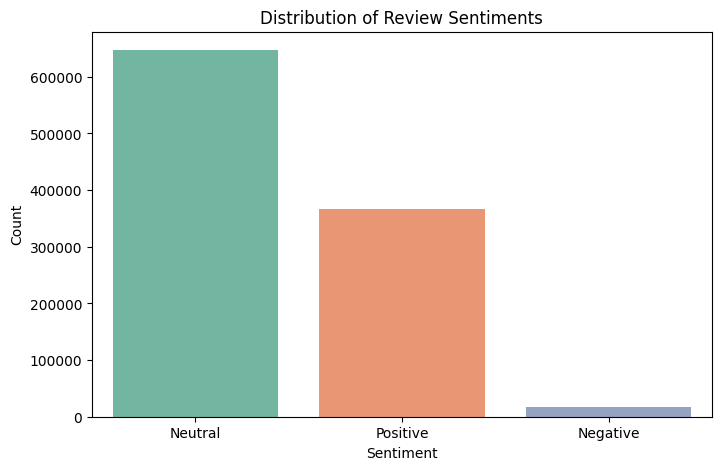

In [52]:
# Visualizing sentiment distribution
plt.figure(figsize=(8,5))
sns.countplot(data=merged_df, x='Sentiment_Label', palette='Set2')
plt.title('Distribution of Review Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()


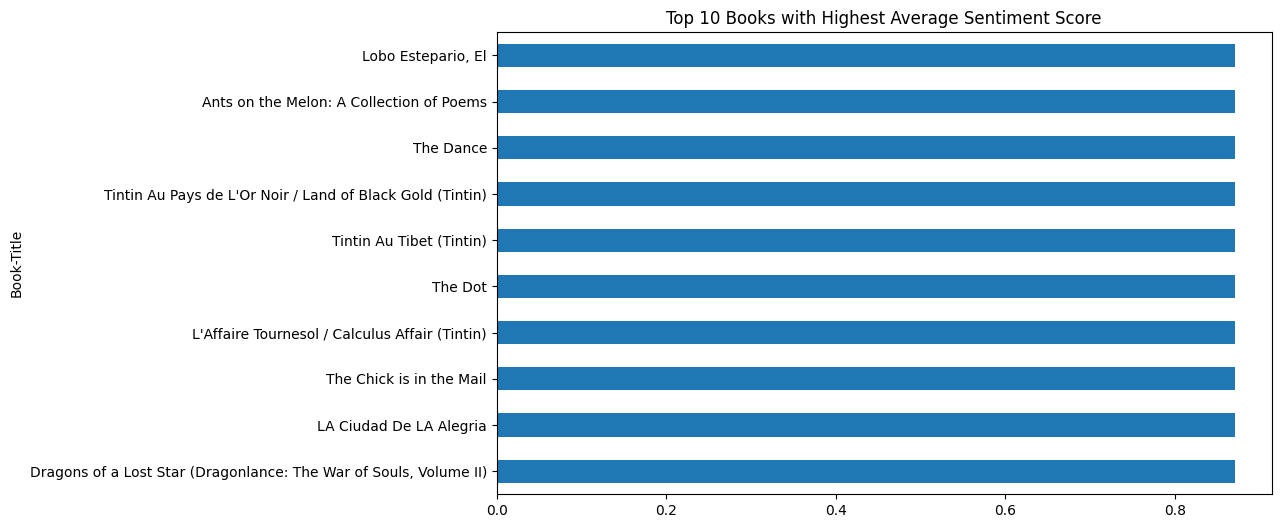

In [53]:
# Average sentiment score per book
book_sentiment = merged_df.groupby('Book-Title')['Sentiment_Score'].mean().sort_values(ascending=False).head(10)
book_sentiment.plot(kind='barh', figsize=(10,6), title='Top 10 Books with Highest Average Sentiment Score')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
# Mood-Based Book Recommendation

In [54]:
merged_df = ratings.merge(books, on='ISBN')
merged_df = merged_df.merge(users, on='User-ID')

In [55]:
# If no review text is present, simulate review from ratings
if 'Review' not in merged_df.columns:
    def generate_review(rating):
        if rating >= 8:
            return "Amazing read, full of joy and excitement!"
        elif rating >= 5:
            return "It was okay, not too exciting but not bad."
        elif rating > 0:
            return "Really slow and boring, felt emotionally down."
        else:
            return np.nan
    merged_df['Review'] = merged_df['Book-Rating'].apply(generate_review)


In [56]:
# Sentiment Analysis using VADER
sid = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    if pd.isna(text):
        return 0
    return sid.polarity_scores(text)['compound']

merged_df['Sentiment_Score'] = merged_df['Review'].apply(get_sentiment_score)

# Mood Mapping
def map_to_mood(score):
    if score >= 0.5:
        return 'Happy'
    elif score <= -0.5:
        return 'Sad'
    else:
        return 'Neutral'

merged_df['Mood'] = merged_df['Sentiment_Score'].apply(map_to_mood)


In [57]:
# Mood-based filtering function
def recommend_books_by_mood(mood, top_n=10):
    mood_books = merged_df[merged_df['Mood'] == mood]
    top_books = mood_books.groupby('Book-Title').size().sort_values(ascending=False).head(top_n)
    return top_books

# Example usage:
print("Books for a 'Happy' mood:")
print(recommend_books_by_mood('Happy'))


Books for a 'Happy' mood:
Book-Title
The Lovely Bones: A Novel                           692
The Da Vinci Code                                   482
The Secret Life of Bees                             398
The Nanny Diaries: A Novel                          371
The Red Tent (Bestselling Backlist)                 369
Bridget Jones's Diary                               357
A Painted House                                     343
Harry Potter and the Chamber of Secrets (Book 2)    325
Life of Pi                                          322
Divine Secrets of the Ya-Ya Sisterhood: A Novel     315
dtype: int64
